<a href="https://colab.research.google.com/github/Vincentlam81/Practical-Exam-2/blob/main/Practical_Exam_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/karpathy/nanoGPT
%cd nanoGPT
!pip install torch numpy transformers datasets tiktoken tqdm matplotlib
!mkdir -p logs figures config/generated external_code

!python data/shakespeare_char/prepare.py

step2_cfg = """
out_dir = 'out-shakespeare-step2-heavier'
eval_interval = 500
log_interval = 10
eval_iters = 70
always_save_checkpoint = True

wandb_log = False

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 48
block_size = 128

n_layer = 7
n_head = 4
n_embd = 224
dropout = 0.2

learning_rate = 1e-3
max_iters = 3500
lr_decay_iters = 3500
min_lr = 1e-4
beta2 = 0.99
warmup_iters = 150

device = 'cuda'
compile = False
"""
with open("config/train_shakespeare_step2_heavier.py", "w") as f:
    f.write(step2_cfg)

print("Created config/train_shakespeare_step2_heavier.py")

!mkdir -p logs
!python train.py config/train_shakespeare_step2_heavier.py | tee logs/log_step2_heavier.txt

!python sample.py --out_dir=out-shakespeare-step2-heavier --start="ROMEO:" --temperature=0.7 --top_k=40

fatal: destination path 'nanoGPT' already exists and is not an empty directory.
/content/nanoGPT
length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens
Created config/train_shakespeare_step2_heavier.py
/content/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
Overriding config with config/train_shakespeare_step2_heavier.py:

out_dir = 'out-shakespeare-step2-heavier'
eval_interval = 500
log_interval = 10
eval_iters = 70
always_save_checkpoint = True

wandb_log = False

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 48
block_size = 128

n_layer = 7
n_head = 4
n_embd = 224
dropout = 0.2

learning_rate = 1e-3
max_iters = 3500
lr_decay_iters = 3500
min_lr =

Generated Step 3 configs:
config/generated/train_shakespeare_l2_h4.py
config/generated/train_shakespeare_l3_h4.py
config/generated/train_shakespeare_l5_h4.py
config/generated/train_shakespeare_l7_h4.py
/content/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
Overriding config with config/generated/train_shakespeare_l2_h4.py:

out_dir = 'out-shakespeare-l2-h4'
eval_interval = 500
log_interval = 10
eval_iters = 50
always_save_checkpoint = True

wandb_log = False

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 32
block_size = 128

n_layer = 2
n_head = 4
n_embd = 160
dropout = 0.2

learning_rate = 1e-3
max_iters = 2500
lr_decay_iters = 2500
min_lr = 1e-4
beta2 = 0.99
warmup_iters = 100

device = 'cuda'
compile = False

tokens per iteration will be: 4,096
found vocab_size = 65 (inside data/shakespea

,n_layer,n_head,iteration,train_loss,val_loss,status
0,2,4,2500,1.6271,1.7844,ok
1,3,4,2500,1.5790,1.7452,ok
2,5,4,2500,1.5588,1.7408,ok
3,7,4,2500,1.5057,1.7004,ok


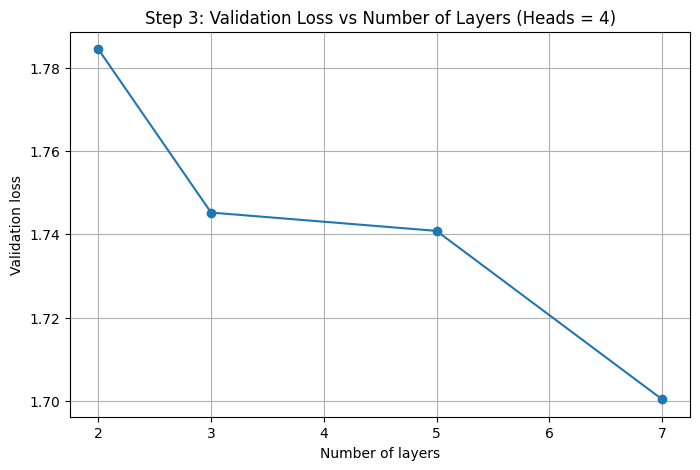

Saved plot to figures/step3_loss_plot.png
Best Step 3 result:


,3
n_layer,7
n_head,4
iteration,2500
train_loss,1.5057
val_loss,1.7004
status,ok


Step 3 summary:
 n_layer  n_head  iteration  train_loss  val_loss status
       2       4       2500      1.6271    1.7844     ok
       3       4       2500      1.5790    1.7452     ok
       5       4       2500      1.5588    1.7408     ok
       7       4       2500      1.5057    1.7004     ok

Best configuration:
n_layer            7
n_head             4
iteration       2500
train_loss    1.5057
val_loss      1.7004
status            ok


In [ ]:
!mkdir -p config/generated
!mkdir -p logs
!mkdir -p figures

from pathlib import Path

base_cfg = """
out_dir = '{out_dir}'
eval_interval = 500
log_interval = 10
eval_iters = 50
always_save_checkpoint = True

wandb_log = False

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 32
block_size = 128

n_layer = {n_layer}
n_head = 4
n_embd = 160
dropout = 0.2

learning_rate = 1e-3
max_iters = 2500
lr_decay_iters = 2500
min_lr = 1e-4
beta2 = 0.99
warmup_iters = 100

device = 'cuda'
compile = False
"""

layers = [2, 3, 5, 7]

for L in layers:
    cfg_text = base_cfg.format(
        out_dir=f"out-shakespeare-l{L}-h4",
        n_layer=L
    )
    path = Path(f"config/generated/train_shakespeare_l{L}_h4.py")
    path.write_text(cfg_text)

print("Generated Step 3 configs:")
for L in layers:
    print(f"config/generated/train_shakespeare_l{L}_h4.py")

!python train.py config/generated/train_shakespeare_l2_h4.py | tee logs/log_l2_h4.txt

!python train.py config/generated/train_shakespeare_l3_h4.py | tee logs/log_l3_h4.txt

!python train.py config/generated/train_shakespeare_l5_h4.py | tee logs/log_l5_h4.txt

!python train.py config/generated/train_shakespeare_l7_h4.py | tee logs/log_l7_h4.txt

import re
import pandas as pd
from pathlib import Path

log_map = {
    2: "logs/log_l2_h4.txt",
    3: "logs/log_l3_h4.txt",
    5: "logs/log_l5_h4.txt",
    7: "logs/log_l7_h4.txt",
}

rows = []

for n_layer, log_file in log_map.items():
    path = Path(log_file)

    if not path.exists():
        rows.append({
            "n_layer": n_layer,
            "n_head": 4,
            "iteration": None,
            "train_loss": None,
            "val_loss": None,
            "status": "log file missing"
        })
        continue

    text = path.read_text(errors="ignore")
    lines = text.splitlines()

    found = []

    for line in lines:
        m = re.search(
            r"(?:step|iter)\s+(\d+).*?train loss\s+([0-9.]+).*?val loss\s+([0-9.]+)",
            line
        )
        if m:
            found.append((
                int(m.group(1)),
                float(m.group(2)),
                float(m.group(3))
            ))

    if not found:
        rows.append({
            "n_layer": n_layer,
            "n_head": 4,
            "iteration": None,
            "train_loss": None,
            "val_loss": None,
            "status": "no val loss found"
        })
        continue

    chosen = None
    for it, tr, va in found:
        if it == 2500:
            chosen = (it, tr, va)
            break

    if chosen is None:
        chosen = found[-1]

    rows.append({
        "n_layer": n_layer,
        "n_head": 4,
        "iteration": chosen[0],
        "train_loss": chosen[1],
        "val_loss": chosen[2],
        "status": "ok"
    })

df = pd.DataFrame(rows).sort_values("n_layer").reset_index(drop=True)
df.to_csv("step3_results.csv", index=False)

print("Parsed Step 3 results:")
display(df)

import matplotlib.pyplot as plt
import os

plot_df = df.dropna(subset=["val_loss"])

if plot_df.empty:
    print("No valid val_loss values to plot.")
else:
    plt.figure(figsize=(8,5))
    plt.plot(plot_df["n_layer"], plot_df["val_loss"], marker="o")
    plt.xlabel("Number of layers")
    plt.ylabel("Validation loss")
    plt.title("Step 3: Validation Loss vs Number of Layers (Heads = 4)")
    plt.grid(True)

    os.makedirs("figures", exist_ok=True)
    plt.savefig("figures/step3_loss_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved plot to figures/step3_loss_plot.png")

valid_df = df.dropna(subset=["val_loss"])

if valid_df.empty:
    print("No valid val_loss values found.")
    print("Check the logs:")
    for f in log_map.values():
        print(" -", f)
else:
    best_row = valid_df.loc[valid_df["val_loss"].idxmin()]
    print("Best Step 3 result:")
    display(best_row)

print("Step 3 summary:")
print(df.to_string(index=False))

valid_df = df.dropna(subset=["val_loss"])
if not valid_df.empty:
    best_row = valid_df.loc[valid_df["val_loss"].idxmin()]
    print("\nBest configuration:")
    print(best_row.to_string())

In [ ]:
!cp -r data/shakespeare_char data/code_generation
!ls data/code_generation
!mkdir -p external_code
%cd /content/nanoGPT/external_code

!git clone https://github.com/pallets/flask.git
!git clone https://github.com/psf/requests.git
!git clone https://github.com/pallets/click.git
!git clone https://github.com/pypa/packaging.git
!git clone https://github.com/urllib3/urllib3.git

%cd /content/nanoGPT

from pathlib import Path

repos_root = Path("/content/nanoGPT/external_code")
output_path = Path("/content/nanoGPT/data/code_generation/input.txt")

py_files = sorted(repos_root.rglob("*.py"))

num_files = 0
num_chars = 0

with output_path.open("w", encoding="utf-8") as out:
    for fp in py_files:
        try:
            text = fp.read_text(encoding="utf-8", errors="ignore")
            if not text.strip():
                continue

            out.write(f"# FILE: {fp}\n")
            out.write(text)
            out.write("\n\n")

            num_files += 1
            num_chars += len(text)
        except Exception as e:
            print("Skipping", fp, e)

print("Files added:", num_files)
print("Total chars:", num_chars)
print("Saved to:", output_path)

!python data/code_generation/prepare.py

code_cfg = """
out_dir = 'out-code-generation'
eval_interval = 500
log_interval = 10
eval_iters = 50
always_save_checkpoint = True

wandb_log = False

dataset = 'code_generation'
gradient_accumulation_steps = 1
batch_size = 32
block_size = 128

n_layer = 5
n_head = 4
n_embd = 160
dropout = 0.2

learning_rate = 1e-3
max_iters = 2500
lr_decay_iters = 2500
min_lr = 1e-4
beta2 = 0.99
warmup_iters = 100

device = 'cuda'
compile = False
"""
with open("config/train_code_generation.py", "w") as f:
    f.write(code_cfg)

print("Created config/train_code_generation.py")

!mkdir -p logs
!python train.py config/train_code_generation.py | tee logs/log_code_generation.txt

!python sample.py --out_dir=out-code-generation --start="def " --temperature=0.7 --top_k=40

!python sample.py --out_dir=out-code-generation --start="class " --temperature=0.7 --top_k=40

!python sample.py --out_dir=out-code-generation --start="import " --temperature=0.7 --top_k=40

!python sample.py --out_dir=out-code-generation --start="def " --temperature=0.7 --top_k=40 > code_sample_def.txt
!python sample.py --out_dir=out-code-generation --start="class " --temperature=0.7 --top_k=40 > code_sample_class.txt
!python sample.py --out_dir=out-code-generation --start="import " --temperature=0.7 --top_k=40 > code_sample_import.txt

!ls -l code_sample_*.txt

!echo "===== def sample ====="
!head -n 20 code_sample_def.txt

!echo "\n===== class sample ====="
!head -n 20 code_sample_class.txt

!echo "\n===== import sample ====="
!head -n 20 code_sample_import.txt

input.txt  meta.pkl  prepare.py  readme.md  train.bin  val.bin
/content/nanoGPT/external_code
Cloning into 'flask'...
remote: Enumerating objects: 26198, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 26198 (delta 2), reused 2 (delta 2), pack-reused 26195 (from 2)
Receiving objects: 100% (26198/26198), 11.69 MiB | 14.02 MiB/s, done.
Resolving deltas: 100% (17513/17513), done.
Cloning into 'requests'...
remote: Enumerating objects: 26726, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 26726 (delta 53), reused 19 (delta 19), pack-reused 26651 (from 3)
Receiving objects: 100% (26726/26726), 13.10 MiB | 18.84 MiB/s, done.
Resolving deltas: 100% (17518/17518), done.
Cloning into 'click'...
remote: Enumerating objects: 14380, done.
remote: Counting objects: 100% (2474/2474), done.
remote: Compressing objects: 100% (344/344), done.
remote: Total 14380 (delta 2296), reused 2130 (delta 2130), pack-reused 11906 

In [ ]:
!zip -r submission.zip /content/nanoGPT

  adding: content/nanoGPT/ (stored 0%)
  adding: content/nanoGPT/code_sample_class.txt (deflated 69%)
  adding: content/nanoGPT/external_code/ (stored 0%)
  adding: content/nanoGPT/external_code/flask/ (stored 0%)
  adding: content/nanoGPT/external_code/flask/.editorconfig (deflated 33%)
  adding: content/nanoGPT/external_code/flask/LICENSE.txt (deflated 48%)
  adding: content/nanoGPT/external_code/flask/tests/ (stored 0%)
  adding: content/nanoGPT/external_code/flask/tests/test_apps/ (stored 0%)
  adding: content/nanoGPT/external_code/flask/tests/test_apps/blueprintapp/ (stored 0%)
  adding: content/nanoGPT/external_code/flask/tests/test_apps/blueprintapp/__init__.py (deflated 44%)
  adding: content/nanoGPT/external_code/flask/tests/test_apps/blueprintapp/apps/ (stored 0%)
  adding: content/nanoGPT/external_code/flask/tests/test_apps/blueprintapp/apps/__init__.py (stored 0%)
  adding: content/nanoGPT/external_code/flask/tests/test_apps/blueprintapp/apps/admin/ (stored 0%)
  adding: co

In [9]:
%cd /content/nanoGPT
!git status
!git config --global user.email "102787970abc@gmail.com"
!git config --global user.name "Vincentlam81"
!git add .
!git commit -m "Add final report and figures"
!git push

/content/nanoGPT
On branch master
Your branch is up to date with 'origin/master'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	code_sample_class.txt
	code_sample_def.txt
	code_sample_import.txt
	config/generated/
	config/train_code_generation.py
	config/train_shakespeare_fast.py
	config/train_shakespeare_step2.py
	config/train_shakespeare_step2_heavier.py
	config/train_shakespeare_step2_slightlylighter.py
	config/train_shakespeare_step2_stronger.py
	data/code_generation/
	external_code/
	figures/
	logs/
	nanoGPT/
	report.md
	step3_results.csv
	submission.zip

nothing added to commit but untracked files present (use "git add" to track)
hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> external_code/click
hint: 